프로젝트 목표 정의
목표
특정 도시의 다음 날 평균 기온 예측

Input: Region, Country, State, City, Date (Year, Month, Day)
Output: AvgTemperature (다음 날)
예측 문제 타입: Time Series Regression

컬럼: Region, Country, State, City, Date (Year, Month, Day), AvgTemperature[평균기온]
City A : 1995 → 2000 ...
City B : 1995 → 2000 ...
City C : ...

확인할 것
데이터 크기
도시 수
연도 범위
결측치
온도 단위

In [1]:
import pandas as pd

df = pd.read_csv("city_temperature.csv")

print(df.shape)
print(df.head())

print(df.isna().sum())
print(df["City"].nunique())
print(df["Country"].nunique())

print(df["Year"].min(), df["Year"].max())

C:\Users\user\AppData\Local\Temp\ipykernel_19372\3491759071.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("city_temperature.csv")


(2906327, 8)
   Region  Country State     City  Month  Day  Year  AvgTemperature
0  Africa  Algeria   NaN  Algiers      1    1  1995            64.2
1  Africa  Algeria   NaN  Algiers      1    2  1995            49.4
2  Africa  Algeria   NaN  Algiers      1    3  1995            48.8
3  Africa  Algeria   NaN  Algiers      1    4  1995            46.4
4  Africa  Algeria   NaN  Algiers      1    5  1995            47.9
Region                  0
Country                 0
State             1450990
City                    0
Month                   0
Day                     0
Year                    0
AvgTemperature          0
dtype: int64
321
125
200 2020


In [2]:
# 에러가 발생한 위치 주변 데이터를 확인 (인덱스가 아니라 58204번째 위치 근처)
print(df.iloc[58200:58210])

# 혹은 상식 밖의 데이터가 있는지 직접 조회
invalid_days = df[(df['Month'] == 2) & (df['Day'] > 29)]
print(invalid_days)

       Region   Country State         City  Month  Day  Year  AvgTemperature
58200  Africa  Ethiopia   NaN  Addis Ababa     12   25   201           -99.0
58201  Africa  Ethiopia   NaN  Addis Ababa     12   26   201           -99.0
58202  Africa  Ethiopia   NaN  Addis Ababa     12   27   201           -99.0
58203  Africa  Ethiopia   NaN  Addis Ababa     12   28   201           -99.0
58204  Africa  Ethiopia   NaN  Addis Ababa     12   29   201           -99.0
58205  Africa  Ethiopia   NaN  Addis Ababa     12   30   201           -99.0
58206  Africa  Ethiopia   NaN  Addis Ababa     12   31   201           -99.0
58207  Africa  Ethiopia   NaN  Addis Ababa      1    1  2015           -99.0
58208  Africa  Ethiopia   NaN  Addis Ababa      1    2  2015           -99.0
58209  Africa  Ethiopia   NaN  Addis Ababa      1    3  2015           -99.0
Empty DataFrame
Columns: [Region, Country, State, City, Month, Day, Year, AvgTemperature]
Index: []


In [3]:
import pandas as pd

# 날짜 조합 시도 (errors='coerce'로 잘못된 날짜는 NaT 처리)
df["date"] = pd.to_datetime(df[["Year","Month","Day"]], errors="coerce")

# NaT가 된 행 확인
invalid_dates = df[df["date"].isna()]
print(invalid_dates)

                                    Region        Country State  \
58204                               Africa       Ethiopia   NaN   
58205                               Africa       Ethiopia   NaN   
58206                               Africa       Ethiopia   NaN   
82774                               Africa         Guinea   NaN   
85697                               Africa         Guinea   NaN   
92041                               Africa  Guinea-Bissau   NaN   
112002                              Africa          Kenya   NaN   
112003                              Africa          Kenya   NaN   
112004                              Africa          Kenya   NaN   
146077                              Africa         Malawi   NaN   
155025                              Africa     Mozambique   NaN   
155026                              Africa     Mozambique   NaN   
155027                              Africa     Mozambique   NaN   
177862                              Africa        Nigeria   Na

In [4]:
df["date"] = pd.to_datetime(df[["Year","Month","Day"]])
df = df.sort_values(["City","date"])

ValueError: cannot assemble the datetimes: day is out of range for month, at position 58204. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [5]:
import pandas as pd

# 1. 연, 월, 일을 문자열로 합칩니다. (예: "2026-2-30")
date_series = (
    df["Year"].astype(str) + "-" + 
    df["Month"].astype(str) + "-" + 
    df["Day"].astype(str)
)

# 2. 이 문자열 시리즈를 변환합니다. 여기서 'coerce'는 오작동 없이 NaT를 만들어줍니다.
df["date"] = pd.to_datetime(date_series, errors="coerce")

# 3. NaT가 발생한 행(58204번째 포함) 확인
print("잘못된 날짜 행 수:", df["date"].isna().sum())
print(df[df["date"].isna()].head())

# 4. 정렬 진행
df = df.sort_values(["City", "date"])

잘못된 날짜 행 수: 448
       Region   Country State         City  Month  Day  Year  AvgTemperature  \
58178  Africa  Ethiopia   NaN  Addis Ababa     12    3   201           -99.0   
58179  Africa  Ethiopia   NaN  Addis Ababa     12    4   201           -99.0   
58180  Africa  Ethiopia   NaN  Addis Ababa     12    5   201           -99.0   
58181  Africa  Ethiopia   NaN  Addis Ababa     12    6   201           -99.0   
58182  Africa  Ethiopia   NaN  Addis Ababa     12    7   201           -99.0   

      date  
58178  NaT  
58179  NaT  
58180  NaT  
58181  NaT  
58182  NaT  


In [6]:
print(df['Year'].unique()) # 201 외에 또 다른 이상한 숫자가 있는지 확인

[1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008
 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020  201  200]


In [7]:
# 1. 날짜 변환 (문자열 결합 방식 + coerce)
df["date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-" + df["Day"].astype(str), 
    errors="coerce"
)

# 2. NaT(200, 201년 등)인 행 삭제
df = df.dropna(subset=['date'])

# 3. 정렬 수행
df = df.sort_values(["City", "date"])

print("정리 후 데이터 크기:", df.shape)
print("연도 확인:", sorted(df['Year'].unique()))

정리 후 데이터 크기: (2905879, 9)
연도 확인: [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [9]:
# 가장 많이 등장하는 온도 값 Top 20 확인
print("--- 빈도수가 높은 온도 값 Top 20 ---")
print(df["AvgTemperature"].value_counts().head(20))

# 전체 온도 종류의 개수
print(f"\n전체 온도의 고유값 개수: {df['AvgTemperature'].nunique()}개")

--- 빈도수가 높은 온도 값 Top 20 ---
AvgTemperature
-99.0    79224
 80.2     7442
 80.8     7362
 81.1     7247
 79.2     7241
 80.5     7223
 82.0     7199
 79.8     7170
 81.3     7069
 79.0     7061
 79.5     7052
 81.7     7040
 79.3     7011
 80.4     7009
 79.6     6959
 82.2     6957
 81.0     6940
 81.5     6928
 79.7     6907
 80.6     6894
Name: count, dtype: int64

전체 온도의 고유값 개수: 1517개


In [12]:
print("--- 온도 데이터 요약 통계 ---")
print(df["AvgTemperature"].describe())

--- 온도 데이터 요약 통계 ---
count    2.905879e+06
mean     5.602882e+01
std      3.206836e+01
min     -9.900000e+01
25%      4.580000e+01
50%      6.250000e+01
75%      7.550000e+01
max      1.100000e+02
Name: AvgTemperature, dtype: float64


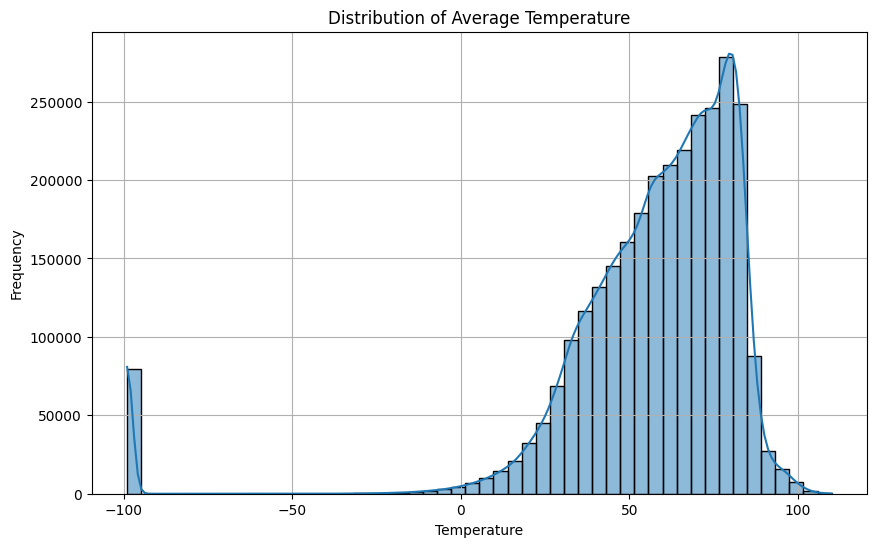

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df["AvgTemperature"], bins=50, kde=True)
plt.title("Distribution of Average Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# 1. 이상치(-99.0 등)를 NaN으로 처리하거나 아예 삭제
# 사용자님의 통찰대로 -50도 이하 데이터는 모두 제거합니다.
df_cleaned = df[df["AvgTemperature"] > -50].copy()

# 2. 화씨(F)를 섭씨(C)로 변환 (필요한 경우)
# 공식: (F - 32) * 5/9
df_cleaned["AvgTemp_Celsius"] = (df_cleaned["AvgTemperature"] - 32) * (5/9)

# 3. 변환 후 다시 한번 분포 확인
print("--- 정제 후 온도 요약 (섭씨) ---")
print(df_cleaned["AvgTemp_Celsius"].describe())

# 4. 정제된 데이터로 히스토그램 다시 그리기
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned["AvgTemp_Celsius"], bins=50, kde=True, color='orange')
plt.title("Distribution of Average Temperature (Celsius)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

--- 정제 후 온도 요약 (섭씨) ---


KeyError: 'AvgTemp_Celsius'

In [17]:
import pandas as pd

# 1. 날짜 변환 및 결측치(NaT) 처리
# 이미 진행하셨던 문자열 결합 방식을 사용하여 안전하게 변환합니다.
df["date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-" + df["Day"].astype(str), 
    errors="coerce"
)

# 2. 유효하지 않은 날짜(NaT)와 이상치(-50도 이하) 제거
# 사용자님이 발견하신 '비어있는 구간'을 기준으로 필터링합니다.
df_refined = df.dropna(subset=['date']).copy()
df_refined = df_refined[df_refined["AvgTemperature"] > -50]

# 3. 도시와 날짜순으로 정렬
df_refined = df_refined.sort_values(["City", "date"])

# --- 결과 확인 ---
print(f"정제 전 데이터 수: {len(df)}")
print(f"정제 후 데이터 수: {len(df_refined)}")
print(f"삭제된 이상치 수: {len(df) - len(df_refined)}")

print("\n--- 정제 후 온도 요약 (°F) ---")
print(df_refined["AvgTemperature"].describe())

# 잘 정제되었는지 고유값 상위 5개 확인 (이제 -99.0이 없어야 합니다)
print("\n--- 정제 후 빈도수 높은 온도 Top 5 ---")
print(df_refined["AvgTemperature"].value_counts().head(5))

정제 전 데이터 수: 2905879
정제 후 데이터 수: 2826654
삭제된 이상치 수: 79225

--- 정제 후 온도 요약 (°F) ---
count    2.826654e+06
mean     6.037392e+01
std      1.909733e+01
min     -4.910000e+01
25%      4.740000e+01
50%      6.330000e+01
75%      7.590000e+01
max      1.100000e+02
Name: AvgTemperature, dtype: float64

--- 정제 후 빈도수 높은 온도 Top 5 ---
AvgTemperature
80.2    7442
80.8    7362
81.1    7247
79.2    7241
80.5    7223
Name: count, dtype: int64


In [18]:
# 중복된 행이 있는지 확인
duplicates = df_refined.duplicated(subset=['City', 'date']).sum()
print(f"중복된 날짜 데이터: {duplicates}건")

# 만약 있다면 제거
# df_refined = df_refined.drop_duplicates(subset=['City', 'date'])

중복된 날짜 데이터: 57248건


In [20]:
# 'City'와 'date'가 모두 똑같은 행들 중 하나만 남기고 삭제
df_refined = df_refined.drop_duplicates(subset=['City', 'date'], keep='first')

print(f"중복 제거 후 데이터 수: {len(df_refined)}")

중복 제거 후 데이터 수: 2769406


In [19]:
# 도시별 데이터 개수 확인
city_counts = df_refined.groupby('City').size().sort_values(ascending=False)
print(city_counts.head(10)) # 데이터가 풍부한 도시
print(city_counts.tail(10)) # 데이터가 너무 적어 분석이 힘든 도시

City
Washington       18498
Washington DC    18498
Portland         18493
Charleston       18490
Columbus         18472
Springfield      18464
Munich            9850
Oslo              9584
Shreveport        9253
Fairbanks         9252
dtype: int64
City
Dhaka         3567
Flagstaff     3545
Pristina      3247
Yerevan       3188
Freetown      3064
Lilongwe      2641
Frankfurt     2331
Georgetown    2136
Bonn          1083
Bujumbura      884
dtype: int64


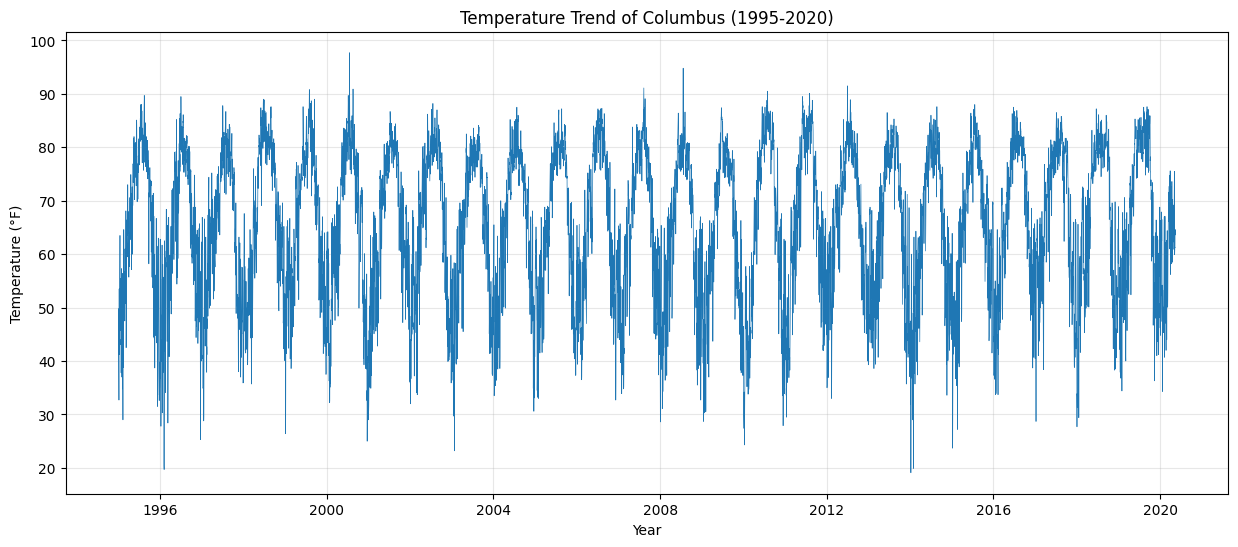

In [21]:
import matplotlib.pyplot as plt

# 1. 데이터가 가장 많은 도시 확인 (예: 'Tokyo' 혹은 'Chicago' 등)
top_city = df_refined['City'].value_counts().idxmax()
city_data = df_refined[df_refined['City'] == top_city]

# 2. 시각화
plt.figure(figsize=(15, 6))
plt.plot(city_data['date'], city_data['AvgTemperature'], linewidth=0.5, color='#1f77b4')
plt.title(f"Temperature Trend of {top_city} (1995-2020)")
plt.xlabel("Year")
plt.ylabel("Temperature (°F)")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# index=False를 설정해야 0, 1, 2... 같은 인덱스 번호가 파일에 추가로 저장되지 않습니다.
df_refined.to_csv("city_temperature_cleaned.csv", index=False)

print("정제된 데이터가 'city_temperature_cleaned.csv'로 저장되었습니다!")

정제된 데이터가 'city_temperature_cleaned.csv'로 저장되었습니다!


In [ ]:
# 새 노트북에서 불러오는 경우 실행
df = pd.read_csv("city_temperature_cleaned.csv", parse_dates=['date'])